# HW2 DETR - Colab Version (Fixed & Optimized)
**Rules respected:**
- ✅ Backbone (ResNet-50) uses pretrained ImageNet weights
- ✅ Encoder–Decoder (Transformer) trained from scratch
- ✅ No fully pretrained DETR loaded
- ✅ Best model saved automatically based on validation loss

In [3]:
!pip install -q transformers torchvision timm

In [4]:
from google.colab import drive
drive.mount('/content/drive')
!unzip -q "/content/drive/MyDrive/nycu-hw2-data.zip" -d /content/

Mounted at /content/drive


In [5]:
import os

DATA_DIR   = "/content/nycu-hw2-data"
TRAIN_JSON = DATA_DIR + "/train.json"
VALID_JSON = DATA_DIR + "/valid.json"
TEST_DIR   = DATA_DIR + "/test"

# Where to save checkpoints (on Drive so they persist if session dies)
SAVE_DIR   = "/content/drive/MyDrive"
BEST_MODEL_PATH  = SAVE_DIR + "/best_detr_model.pth"
FINAL_MODEL_PATH = SAVE_DIR + "/final_detr_model.pth"

print(f"DATA_DIR  : {DATA_DIR}")
print(f"TRAIN_JSON: {TRAIN_JSON}")
print(f"VALID_JSON: {VALID_JSON}")
print(f"TEST_DIR  : {TEST_DIR}")

DATA_DIR  : /content/nycu-hw2-data
TRAIN_JSON: /content/nycu-hw2-data/train.json
VALID_JSON: /content/nycu-hw2-data/valid.json
TEST_DIR  : /content/nycu-hw2-data/test


In [6]:
import torch
import torchvision
from torch.utils.data import DataLoader
from transformers import DetrForObjectDetection, DetrImageProcessor, DetrConfig
from PIL import Image
import json
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"PyTorch version: {torch.__version__}")

Device: cuda
GPU: NVIDIA A100-SXM4-80GB
PyTorch version: 2.10.0+cu128


In [7]:
with open(TRAIN_JSON) as f:
    train_coco = json.load(f)

with open(VALID_JSON) as f:
    valid_coco = json.load(f)

print(f"Train images : {len(train_coco['images'])}")
print(f"Train anns   : {len(train_coco['annotations'])}")
print(f"Valid images : {len(valid_coco['images'])}")
print(f"Categories   : {len(train_coco['categories'])}")

Train images : 30062
Train anns   : 65960
Valid images : 3340
Categories   : 10


In [8]:
# Processor used by DETR for resizing / normalization / padding
# We let the processor handle the resize to avoid double-resizing.
processor = DetrImageProcessor.from_pretrained(
    "facebook/detr-resnet-50",
    do_resize=True,
    size={"shortest_edge": 800, "longest_edge": 1333},
    do_rescale=True,
    do_normalize=True
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/290 [00:00<?, ?B/s]

In [9]:
import os
import random
import torch
import torchvision.transforms.functional as TF
from PIL import Image

# Build explicit mappings:
# COCO category ids in the homework start at 1
# DETR training should use contiguous labels 0..N-1
sorted_categories = sorted(train_coco["categories"], key=lambda c: c["id"])
cat_id_to_label = {cat["id"]: idx for idx, cat in enumerate(sorted_categories)}
label_to_cat_id = {idx: cat["id"] for idx, cat in enumerate(sorted_categories)}

print("COCO category_id -> model label:", cat_id_to_label)
print("Model label -> COCO category_id:", label_to_cat_id)


class CocoDataset(torch.utils.data.Dataset):
    def __init__(self, img_dir, coco, cat_id_to_label, augment=False):
        self.img_dir = img_dir
        self.coco = coco
        self.cat_id_to_label = cat_id_to_label
        self.augment = augment

        valid_ids = set()
        for img_info in coco["images"]:
            img_path = os.path.join(img_dir, img_info["file_name"])
            if os.path.exists(img_path):
                valid_ids.add(img_info["id"])

        self.images = [img for img in coco["images"] if img["id"] in valid_ids]

        self.annotations = []
        for ann in coco["annotations"]:
            if ann["image_id"] not in valid_ids:
                continue

            x, y, w, h = ann["bbox"]
            if w <= 1 or h <= 1:
                continue
            if not all(isinstance(v, (int, float)) for v in ann["bbox"]):
                continue
            if ann["category_id"] not in self.cat_id_to_label:
                continue

            self.annotations.append(ann)

        self.img_to_anns = {}
        for ann in self.annotations:
            self.img_to_anns.setdefault(ann["image_id"], []).append(ann)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_info = self.images[idx]
        img_path = os.path.join(self.img_dir, img_info["file_name"])

        image = Image.open(img_path).convert("RGB")
        img_w, img_h = image.size

        anns = self.img_to_anns.get(img_info["id"], [])
        safe_anns = []

        for ann in anns:
            x, y, w, h = ann["bbox"]

            # Clip bbox to image boundaries
            x = max(0.0, min(float(x), img_w - 1))
            y = max(0.0, min(float(y), img_h - 1))
            w = min(float(w), img_w - x)
            h = min(float(h), img_h - y)

            if w <= 1 or h <= 1:
                continue

            # Remap category_id from COCO ids (1..N) to DETR labels (0..N-1)
            model_label = self.cat_id_to_label[ann["category_id"]]

            new_ann = {
                "id": ann.get("id", -1),
                "image_id": ann["image_id"],
                "category_id": model_label,
                "bbox": [x, y, w, h],
                "area": float(w * h),
                "iscrowd": int(ann.get("iscrowd", 0)),
            }
            safe_anns.append(new_ann)

        if self.augment:
            # Horizontal flip
            if random.random() < 0.5:
                image = TF.hflip(image)
                flipped_anns = []
                for ann in safe_anns:
                    x, y, w, h = ann["bbox"]
                    new_x = img_w - x - w
                    new_ann = dict(ann)
                    new_ann["bbox"] = [new_x, y, w, h]
                    new_ann["area"] = float(w * h)
                    flipped_anns.append(new_ann)
                safe_anns = flipped_anns

            # Mild color augmentation only on the image
            if random.random() < 0.5:
                brightness = 1.0 + random.uniform(-0.15, 0.15)
                contrast = 1.0 + random.uniform(-0.15, 0.15)
                saturation = 1.0 + random.uniform(-0.15, 0.15)

                image = TF.adjust_brightness(image, brightness)
                image = TF.adjust_contrast(image, contrast)
                image = TF.adjust_saturation(image, saturation)

        target = {
            "image_id": img_info["id"],
            "annotations": safe_anns
        }

        return image, target

COCO category_id -> model label: {1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5, 7: 6, 8: 7, 9: 8, 10: 9}
Model label -> COCO category_id: {0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7, 7: 8, 8: 9, 9: 10}


In [10]:
def make_collate_fn(processor):
    def collate_fn(batch):
        images = [item[0] for item in batch]
        targets = [item[1] for item in batch]

        encoding = processor(
            images=images,
            annotations=targets,
            return_tensors="pt"
        )

        return {
            "pixel_values": encoding["pixel_values"],
            "pixel_mask": encoding["pixel_mask"],
            "labels": encoding["labels"],
        }

    return collate_fn

In [11]:
train_dataset = CocoDataset(
    DATA_DIR + "/train",
    train_coco,
    cat_id_to_label=cat_id_to_label,
    augment=True
)

valid_dataset = CocoDataset(
    DATA_DIR + "/valid",
    valid_coco,
    cat_id_to_label=cat_id_to_label,
    augment=False
)

train_collate = make_collate_fn(processor)
valid_collate = make_collate_fn(processor)

BATCH_SIZE = 16
NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=train_collate,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=False
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=valid_collate,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=False
)

print(f"Train images  : {len(train_dataset)}")
print(f"Valid images  : {len(valid_dataset)}")
print(f"Train batches : {len(train_loader)}")
print(f"Valid batches : {len(valid_loader)}")

Train images  : 30062
Valid images  : 3340
Train batches : 1879
Valid batches : 209


In [12]:
# ============================================================
# MODEL SETUP
# Rules:
#   - Backbone (ResNet-50) → pretrained ImageNet weights ✅
#   - Encoder + Decoder (Transformer) → trained from scratch ✅
#   - NOT loading a fully pretrained DETR ✅
# ============================================================

NUM_CLASSES = len(train_coco['categories'])  # number of real classes (no background)
print(f"Number of classes (excl. background): {NUM_CLASSES}")

# Step 1: Load config from the reference architecture (architecture params only)
config = DetrConfig.from_pretrained("facebook/detr-resnet-50")
config.num_labels = NUM_CLASSES  # HuggingFace DETR adds +1 for 'no-object' internally
config.num_queries = 100

# Optionally tune transformer capacity (can improve accuracy without much overhead)
# Default: d_model=256, nheads=8, enc_layers=6, dec_layers=6
# These are kept at default — good balance for training from scratch.

# Step 2: Instantiate model WITHOUT pretrained weights
model = DetrForObjectDetection(config)

# Step 3: Load ONLY the backbone weights from a pretrained ResNet-50
#   We use torchvision's pretrained ResNet-50 and copy matching weights
import torchvision.models as tvm

resnet50_pretrained = tvm.resnet50(weights=tvm.ResNet50_Weights.IMAGENET1K_V1)

# DETR's backbone is wrapped in model.model.backbone.conv_encoder.model
detr_backbone = model.model.backbone.conv_encoder.model

# Copy weights layer by layer (only matching keys)
pretrained_state = resnet50_pretrained.state_dict()
backbone_state   = detr_backbone.state_dict()

matched, skipped = 0, 0
new_state = {}
for k in backbone_state:
    if k in pretrained_state and pretrained_state[k].shape == backbone_state[k].shape:
        new_state[k] = pretrained_state[k]
        matched += 1
    else:
        new_state[k] = backbone_state[k]  # keep random init
        skipped += 1

detr_backbone.load_state_dict(new_state, strict=True)
del resnet50_pretrained  # free memory

print(f"Backbone weights loaded — matched: {matched}, skipped: {skipped}")
print("Transformer encoder/decoder: initialized from scratch ✅")

model = model.to(device)

Number of classes (excl. background): 10


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 242MB/s]


Backbone weights loaded — matched: 265, skipped: 0
Transformer encoder/decoder: initialized from scratch ✅


In [13]:
# ============================================================
# MODEL SETUP
# Backbone: pretrained ResNet-50 only
# Transformer encoder/decoder: trained from scratch
# ============================================================

import torchvision.models as tvm
from transformers import DetrConfig, DetrForObjectDetection

NUM_CLASSES = len(sorted_categories)
print(f"Number of classes: {NUM_CLASSES}")

model_id2label = {i: str(label_to_cat_id[i]) for i in range(NUM_CLASSES)}
model_label2id = {v: k for k, v in model_id2label.items()}

config = DetrConfig.from_pretrained("facebook/detr-resnet-50")
config.num_labels = NUM_CLASSES
config.num_queries = 100
config.auxiliary_loss = True
config.id2label = model_id2label
config.label2id = model_label2id

model = DetrForObjectDetection(config)

# Load ONLY ResNet-50 backbone pretrained weights
resnet50_pretrained = tvm.resnet50(weights=tvm.ResNet50_Weights.IMAGENET1K_V2)
detr_backbone = model.model.backbone.conv_encoder.model

pretrained_state = resnet50_pretrained.state_dict()
backbone_state = detr_backbone.state_dict()

matched, skipped = 0, 0
new_state = {}

for k in backbone_state:
    if k in pretrained_state and pretrained_state[k].shape == backbone_state[k].shape:
        new_state[k] = pretrained_state[k]
        matched += 1
    else:
        new_state[k] = backbone_state[k]
        skipped += 1

detr_backbone.load_state_dict(new_state, strict=True)
del resnet50_pretrained

print(f"Backbone weights loaded — matched: {matched}, skipped: {skipped}")
print("Transformer encoder/decoder initialized from scratch.")

model = model.to(device)

Number of classes: 10
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 239MB/s]


Backbone weights loaded — matched: 265, skipped: 0
Transformer encoder/decoder initialized from scratch.


In [14]:
# ============================================================
# OPTIMIZER & SCHEDULER
# ============================================================

BACKBONE_LR = 1e-5
TRANSFORMER_LR = 1e-4
WEIGHT_DECAY = 1e-4
NUM_EPOCHS = 80

param_dicts = [
    {
        "params": [
            p for n, p in model.named_parameters()
            if "backbone" not in n and p.requires_grad
        ],
        "lr": TRANSFORMER_LR,
    },
    {
        "params": [
            p for n, p in model.named_parameters()
            if "backbone" in n and p.requires_grad
        ],
        "lr": BACKBONE_LR,
    },
]

optimizer = torch.optim.AdamW(param_dicts, weight_decay=WEIGHT_DECAY)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-6
)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")

Trainable parameters: 41,281,551


In [15]:
from tqdm import tqdm
import torch
import torch.amp as amp
import os # Import os module to check for file existence

use_amp = (device.type == "cuda")

try:
    scaler = amp.GradScaler(device.type)
except TypeError:
    scaler = amp.GradScaler(enabled=use_amp)

train_losses = []
valid_losses = []
best_valid_loss = float("inf")
best_epoch = -1
start_epoch = 0 # Initialize start_epoch

# --- Resume training logic ---
if os.path.exists(BEST_MODEL_PATH):
    print(f"Resuming training from checkpoint: {BEST_MODEL_PATH}")
    checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch"]
    best_valid_loss = checkpoint["valid_loss"]
    print(f"Loaded model from epoch {start_epoch} with valid loss {best_valid_loss:.4f}")
    print("Note: train_losses and valid_losses history will restart from this point.")
else:
    print("No existing checkpoint found. Starting training from scratch.")
# ------------------------------

print(f"Starting training for {NUM_EPOCHS - start_epoch} epochs (total {NUM_EPOCHS} epochs)")
print(f"Best model path: {BEST_MODEL_PATH}")
print("=" * 60)

for epoch in range(start_epoch, NUM_EPOCHS):
    # -------------------------
    # TRAIN
    # -------------------------
    model.train()
    total_train_loss = 0.0
    train_steps = 0

    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{NUM_EPOCHS} [Train]")

    for batch in train_pbar:
        pixel_values = batch["pixel_values"].to(device, non_blocking=True)
        pixel_mask = batch["pixel_mask"].to(device, non_blocking=True)
        labels = [
            {k: v.to(device, non_blocking=True) for k, v in t.items()}
            for t in batch["labels"]
        ]

        optimizer.zero_grad(set_to_none=True)

        with amp.autocast(device_type=device.type, enabled=use_amp):
            outputs = model(
                pixel_values=pixel_values,
                pixel_mask=pixel_mask,
                labels=labels
            )
            loss = outputs.loss

        if not torch.isfinite(loss):
            raise RuntimeError(f"Non-finite training loss encountered: {loss.item()}")

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.1)

        scaler.step(optimizer)
        scaler.update()

        total_train_loss += loss.item()
        train_steps += 1

        train_pbar.set_postfix(loss=f"{loss.item():.4f}")

    avg_train_loss = total_train_loss / max(train_steps, 1)
    train_losses.append(avg_train_loss)

    # -------------------------
    # VALID
    # -------------------------
    model.eval()
    total_valid_loss = 0.0
    valid_steps = 0

    valid_pbar = tqdm(valid_loader, desc=f"Epoch {epoch+1:02d}/{NUM_EPOCHS} [Valid]")

    with torch.no_grad():
        for batch in valid_pbar:
            pixel_values = batch["pixel_values"].to(device, non_blocking=True)
            pixel_mask = batch["pixel_mask"].to(device, non_blocking=True)
            labels = [
                {k: v.to(device, non_blocking=True) for k, v in t.items()}
                for t in batch["labels"]
            ]

            with amp.autocast(device_type=device.type, enabled=use_amp):
                outputs = model(
                    pixel_values=pixel_values,
                    pixel_mask=pixel_mask,
                    labels=labels
                )
                loss = outputs.loss

            if not torch.isfinite(loss):
                raise RuntimeError(f"Non-finite validation loss encountered: {loss.item()}")

            total_valid_loss += loss.item()
            valid_steps += 1

    avg_valid_loss = total_valid_loss / max(valid_steps, 1)
    valid_losses.append(avg_valid_loss)

    # The scheduler step should be called with the actual epoch number for correct behavior
    # If resuming, `epoch` already reflects the correct step within the overall NUM_EPOCHS
    scheduler.step(epoch) # Pass the current epoch to the scheduler

    lr_backbone = optimizer.param_groups[1]["lr"]
    lr_transformer = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Valid Loss: {avg_valid_loss:.4f} | "
        f"LR transformer: {lr_transformer:.2e} | "
        f"LR backbone: {lr_backbone:.2e}"
    )

    if avg_valid_loss < best_valid_loss:
        best_valid_loss = avg_valid_loss
        best_epoch = epoch + 1

        torch.save(
            {
                "epoch": best_epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "train_loss": avg_train_loss,
                "valid_loss": avg_valid_loss,
                "num_classes": NUM_CLASSES,
            },
            BEST_MODEL_PATH
        )
        print(f"Best model saved at epoch {best_epoch} (valid loss = {best_valid_loss:.4f})")

print("=" * 60)
print(f"Training complete. Best epoch: {best_epoch} | Best valid loss: {best_valid_loss:.4f}")

Resuming training from checkpoint: /content/drive/MyDrive/best_detr_model.pth
Loaded model from epoch 15 with valid loss 17.2545
Note: train_losses and valid_losses history will restart from this point.
Starting training for 65 epochs (total 80 epochs)
Best model path: /content/drive/MyDrive/best_detr_model.pth


Epoch 16/80 [Valid]: 100%|██████████| 209/209 [01:25<00:00,  2.45it/s]
/tmp/ipykernel_476/4233066470.py:121: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  scheduler.step(epoch) # Pass the current epoch to the scheduler


Epoch 16/80 | Train Loss: 6.4550 | Valid Loss: 17.5456 | LR transformer: 9.17e-05 | LR backbone: 9.24e-06


Epoch 17/80 [Valid]: 100%|██████████| 209/209 [01:26<00:00,  2.43it/s]


Epoch 17/80 | Train Loss: 6.3928 | Valid Loss: 16.4374 | LR transformer: 9.05e-05 | LR backbone: 9.14e-06
Best model saved at epoch 17 (valid loss = 16.4374)


...

Epoch 59/80 | Train Loss: 3.7191 | Valid Loss: 14.0638 | LR transformer: 1.84e-05 | LR backbone: 2.58e-06


Epoch 60/80 [Valid]: 100%|██████████| 209/209 [01:29<00:00,  2.33it/s]


Epoch 60/80 | Train Loss: 3.6749 | Valid Loss: 15.4815 | LR transformer: 1.69e-05 | LR backbone: 2.45e-06


Epoch 61/80 [Train]:   1%|          | 18/1879 [00:09<14:22,  2.16it/s, loss=3.4092]Exception in thread Thread-96 (_pin_memory_loop):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py", line 52, in _pin_memory_loop
    do_one_step()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py", line 28, in do_one_step
    r = in_queue.get(timeout=MP_STATUS_CHECK_INTERVAL)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/multiprocessing/reductions.py", line 540, in rebuild_storage_fd
    fd = df.

KeyboardInterrupt: 

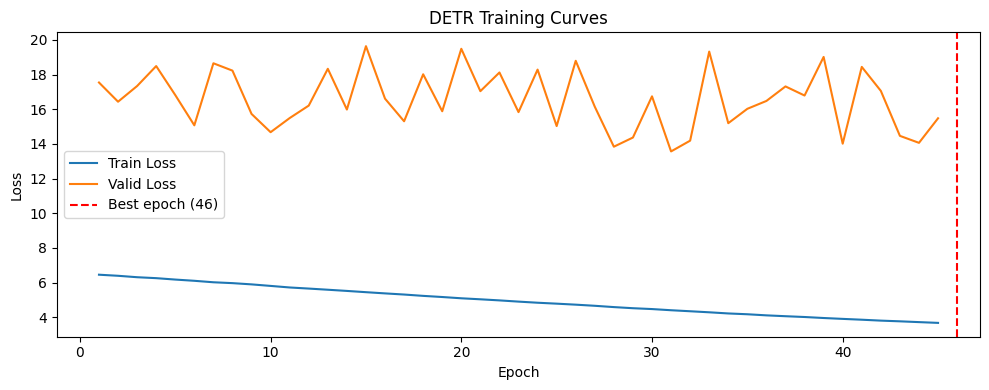

Training curve saved.


In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss")
ax.plot(range(1, len(valid_losses) + 1), valid_losses, label="Valid Loss")
ax.axvline(best_epoch, color="red", linestyle="--", label=f"Best epoch ({best_epoch})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("DETR Training Curves")
ax.legend()
plt.tight_layout()
plt.savefig(SAVE_DIR + "/training_curve.png", dpi=150)
plt.show()

print("Training curve saved.")

In [ ]:
torch.save(
    {
        "epoch": NUM_EPOCHS,
        "model_state_dict": model.state_dict(),
        "train_loss": train_losses[-1] if train_losses else None,
        "valid_loss": valid_losses[-1] if valid_losses else None,
        "num_classes": NUM_CLASSES,
    },
    FINAL_MODEL_PATH
)

print(f"Final model saved to: {FINAL_MODEL_PATH}")
print(f"Best model saved to : {BEST_MODEL_PATH} (epoch {best_epoch})")

In [ ]:
import os
import json
import torch
from PIL import Image
from tqdm import tqdm
from transformers import DetrConfig, DetrForObjectDetection, DetrImageProcessor

OUTPUT_JSON = SAVE_DIR + "/pred.json"
SCORE_THRESHOLD = 0.20
BATCH_SIZE_INFER = 8

print("Model label -> COCO category_id:", label_to_cat_id)

# Reload best model
config_infer = DetrConfig.from_pretrained("facebook/detr-resnet-50")
config_infer.num_labels = NUM_CLASSES
config_infer.num_queries = 100
config_infer.auxiliary_loss = True
config_infer.id2label = model_id2label
config_infer.label2id = model_label2id

model_infer = DetrForObjectDetection(config_infer)

checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
model_infer.load_state_dict(checkpoint["model_state_dict"])
model_infer.to(device)
model_infer.eval()

processor_infer = DetrImageProcessor.from_pretrained(
    "facebook/detr-resnet-50",
    do_resize=True,
    size={"shortest_edge": 800, "longest_edge": 1333},
    do_rescale=True,
    do_normalize=True
)

print(
    f"Best model loaded from epoch {checkpoint['epoch']} "
    f"(valid loss: {checkpoint['valid_loss']:.4f})"
)

test_images = sorted(
    [f for f in os.listdir(TEST_DIR) if f.lower().endswith((".png", ".jpg", ".jpeg"))]
)
print(f"Found {len(test_images)} test images")

predictions = []

def chunks(lst, n):
    for i in range(0, len(lst), n):
        yield lst[i:i + n]

with torch.no_grad():
    for batch_fnames in tqdm(list(chunks(test_images, BATCH_SIZE_INFER)), desc="Inference"):
        images = []
        orig_sizes = []
        image_ids = []

        for fname in batch_fnames:
            stem = os.path.splitext(fname)[0]
            image_id = int(stem) if stem.isdigit() else stem

            image = Image.open(os.path.join(TEST_DIR, fname)).convert("RGB")
            orig_w, orig_h = image.size

            images.append(image)
            orig_sizes.append((orig_h, orig_w))
            image_ids.append(image_id)

        inputs = processor_infer(images=images, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}

        outputs = model_infer(**inputs)

        target_sizes = torch.tensor(orig_sizes, device=device)
        results_batch = processor_infer.post_process_object_detection(
            outputs,
            threshold=SCORE_THRESHOLD,
            target_sizes=target_sizes
        )

        for image_id, results in zip(image_ids, results_batch):
            scores = results["scores"].cpu().tolist()
            labels = results["labels"].cpu().tolist()
            boxes = results["boxes"].cpu().tolist()

            for score, label, box in zip(scores, labels, boxes):
                x0, y0, x1, y1 = box

                coco_category_id = label_to_cat_id[int(label)]

                predictions.append(
                    {
                        "image_id": image_id,
                        "bbox": [
                            float(x0),
                            float(y0),
                            float(x1 - x0),
                            float(y1 - y0),
                        ],
                        "score": float(score),
                        "category_id": int(coco_category_id),
                    }
                )

with open(OUTPUT_JSON, "w") as f:
    json.dump(predictions, f)

print(f"Done — {len(predictions)} predictions saved to {OUTPUT_JSON}")

if len(predictions) > 0:
    print("First 5 predictions:")
    for p in predictions[:5]:
        print(p)